# Imports

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import special
from scipy.special import factorial,factorial2
from scipy.optimize import root_scalar
from scipy.interpolate import CubicSpline

from ppxf.ppxf import ppxf,losvd_rfft,rebin
from ppxf.ppxf_util import convolve_gauss_hermite,log_rebin

c = 299792.458 
fwhm_factor = 2*np.sqrt(2*np.log(2)) #approx 2.355

# Main Functions

## Gauss-Hermite Series

In [10]:
def losvd_norm(pars):
    """
    Normalisation term of the GH series
    """
    herm = pars[3::2] #grab only the even moments since others are zero
    m = (np.arange(len(herm))+2)*2
    
    return 1 + np.sum(herm*factorial2(m-1)/np.sqrt(factorial(m)))

def losvd(v,pars):
    """
    GH series with parameters pars evaluated at v
    """
    V,sigma = pars[:2]
    mom = len(pars)
    n=np.arange(3,mom+1)
    nrm = np.sqrt(special.factorial(n)*2**n)
    coeff = np.append([1,0,0],pars[2:]/nrm)
    y = (v-V)/sigma
    hseries = np.polynomial.hermite.hermval(y,coeff)
    
    out = np.exp(-y**2/2)/(np.sqrt(2*np.pi)*sigma)*hseries
    out = np.atleast_1d(out)
        
    norm = losvd_norm(pars)
    
    return out/norm

## MARCS Library

In [11]:
def load_marcs(lam_range=None,npix=1,return_pop=0):

    main = 'SSP_M11_MARCS/'

    #file1 = main + 'ssp_M11_MARCS.krz002' #13 stars with ages from 3 - 15 Gyr
    #file2 = main + 'ssp_M11_MARCS.krz004' #13 stars with ages from 3 - 15 Gyr
    #file3 = main + 'ssp_M11_MARCS.krz10m4' #5 stars with ages from 7 - 11 Gyr

    file1 = main + 'ssp_M11_MARCS.ssz002' #13 stars with ages from 3 - 15 Gyr
    file2 = main + 'ssp_M11_MARCS.ssz004' #13 stars with ages from 3 - 15 Gyr
    file3 = main + 'ssp_M11_MARCS.ssz10m4' #5 stars with ages from 7 - 11 Gyr

    #Data is organized as
    #Age (Gyr) | [Fe/H] | Wavelength (AA) | Flux (ergs /s /AA /Msun) |
    #wavelength is logarithmically binned

    lam  = np.zeros(100724) #13 stars with 100724 bins
    flux = np.zeros((31,100724)) #13 + 13 + 5 stars
    ages = np.zeros(31)
    metals = np.zeros(31)
    
    
    #Load in z002
    f = open(file1, 'r')
    i=0
    for line in f:
        ldat = line.split()

        index1 = i//100724
        index2 = i%100724

        ages[index1]   = ldat[0]
        metals[index1] = ldat[1]
        lam[index2]    = ldat[2]
        flux[index1,index2] = ldat[3]

        i += 1

    f.close()
    
    #Load in z004
    f = open(file2, 'r')
    i=0
    for line in f:
        ldat = line.split()

        index1 = i//100724 + 13
        index2 = i%100724

        ages[index1]   = ldat[0]
        metals[index1] = ldat[1]
        flux[index1,index2] = ldat[3]

        i += 1
        
    #Load in z10m4
    f = open(file3, 'r')
    i=0
    for line in f:
        ldat = line.split()

        index1 = i//100724 + 13 + 13
        index2 = i%100724

        ages[index1]   = ldat[0]
        metals[index1] = ldat[1]
        flux[index1,index2] = ldat[3]

        i += 1
        
    ln_lam = np.linspace(np.log(lam)[0],np.log(lam)[-1],100724)
    lam = np.exp(ln_lam)

    f.close()
    
    if lam_range != None:
        cut = np.logical_and(lam>=lam_range[0],lam<=lam_range[1])
        lam = lam[cut]
        flux = (flux.T[cut]).T
        
    if npix != 1:
        log_pixel_size = np.diff(np.log(lam))[0] #calculate pixel size in log
        log_boundary = np.append(np.log(lam)-log_pixel_size/2,np.log(lam)[-1]+log_pixel_size/2)
        boundary = np.exp(log_boundary)
        pixel_size = np.diff(boundary)
        
        lam_shape = lam.shape[0]
        ind = npix*np.arange(lam_shape//npix)

        #sum the flux/wavelength and then multiply by the final pixelsize to conserve flux
        flux_rebin  = np.add.reduceat((flux/pixel_size).T,ind)[:-1]
        flux_rebin = (flux_rebin.T*np.diff(boundary[::npix])[:-1]).T
        flux_rebin /= npix**2

        #Calculate lam_rebin by averaging adjacent boundaries
        kernel = np.array([1, 1])
        lam_rebin = np.convolve(boundary[::npix][:-1], kernel, mode='valid')/2
    else:
        lam_rebin = lam
        flux_rebin = flux
        
    if return_pop:
        return lam_rebin,flux_rebin.T,ages,metals
    else:
        return lam_rebin,flux_rebin.T#,ages,metals


## FWHM Scaling

These functions provide a simple way to measure the FWHM of a LSF described as a GH series as well as scaling a LSF GH series to an arbitrary FWHM

In [4]:
def lsf_fwhm(klist):
    """
    klist is the terms in the GH series for the LSF [V,sigma,h3,h4,...]
    """
    sig = klist[1]
    v = np.linspace(-10*sig,10*sig,1001)
    los = losvd(v,klist)

    mlos = np.max(los)
    ind = np.argmax(los)
    vmid = v[ind]

    def root(v):
        return losvd(np.atleast_1d(v),klist)[0]-mlos/2

    sol1 = root_scalar(root, bracket=[v[0], vmid], method='brentq')
    sol2 = root_scalar(root, bracket=[vmid,  v[-1]], method='brentq')

    return sol2.root - sol1.root

def fwhm_scale(fwhm,klist):
    """
    scale GH series LSF klist so it has desired fwhm
    """

    klist_c = klist.copy()
    fwhm1 = lsf_fwhm(klist_c)
    
    klist_c[1] *= fwhm/fwhm1

    return klist_c


## Convolution for Template and Target Spectra

In [5]:
def convolve_variable_lsf(x, y, sig_x, lsf_list, xout=None, oversample=10,velscale_ratio=1,cubic=1):
    """
    Function to convolve a linearly spaced spectrum with a wavelength dependent LSF 

    x = linearly spaced wavelength
    y = linearly spaced spectrum
    sig_x = wavelength dependent sigma (sigma = FWHM/2.355)
    lsf_list = GH series coeffients for the LSF [V, sigma, h3, h4, ...]

    This functions combines Varsmooth and Convolve_Gauss_hermite from the pPXF package
    """
    fwhm_factor = 2*np.sqrt(2*np.log(2)) #approx 2.355

    n_sigs = len(np.unique(sig_x))
    if n_sigs==1:
        dx = np.diff(x)
        assert np.all(np.isclose(
            dx[0], dx)), "`x` must be uniformly spaced, when `sig_x` is a scalar"
        n = len(x)
        sig_max = sig_x[0]*(n - 1)/(x[-1] - x[0])
        y_new = y.T
    else:
        assert len(x) == len(sig_x), "`x` and `sig_x` must have the same length"
            
        # Stretches spectrum to have equal sigma in the new coordinate
        sig = sig_x/np.gradient(x)
        sig = sig.clip(0.1)   # Clip to >=0.1 pixels
        sig_max = np.max(sig)*oversample
        xs = np.cumsum(sig_max/sig)
        n = int(np.ceil(xs[-1] - xs[0]))
        x_new = np.linspace(xs[0], xs[-1], n)
        #y_new = interp(x_new, xs, y.T)
        if cubic:
            y_new = CubicSpline(xs, y.T)(x_new)
        else:
            y_new = interp(x_new, xs, y.T)

    #Take FFT of template spectrum
    npad = 2**int(np.ceil(np.log2(n)))
    templates_rfft = np.fft.rfft(y_new, npad)

    #Set the LSF shape to have a sigma of sig_max
    lsf_list = fwhm_scale(sig_max*fwhm_factor,lsf_list)
    
    # Generate FFT of GH series
    lvd_rfft = losvd_rfft(lsf_list, 1, lsf_list.shape, templates_rfft.shape[0],
                          1, 0, velscale_ratio, 0)

    yout = np.fft.irfft(templates_rfft*lvd_rfft[:, 0,0], npad)[..., :n]

    if n_sigs != 1:
        if xout is not None:
            xs = np.interp(xout, x, xs)  # xs is 1-dim
        if cubic:
            yout = CubicSpline(x_new, yout)(xs)
        else:
            yout = interp(xs, x_new, yout)

    return yout.T


    
def target_spectrum(lam,template,sigma_lsf,klist_lsf,klist_losvd,lam_range=[4800,8950],cubic=1):
    """
    This function generates the target spectrum from an original ideal, linearly spaced spectrum

    lam = linearly spaced wavelength
    template = linearly spaced spectrum
    sigma_lsf = wavelength dependent sigma (sigma = FWHM/2.355)
    klist_lsf = GH series coeffients for the LSF [V, sigma, h3, h4, ...]
    klist_losvd = GH series coeffients for the LOSVD [V, sigma, h3, h4, ...]
    """
    #perform wavelength dependent convolution
    lsf_spec = convolve_variable_lsf(lam, template, sigma_lsf, klist_lsf,oversample=10,cubic=cubic)

    #log rebin
    velscale = c*np.log(lam[-1]/lam[-2])
    template,lam,_ = log_rebin(lam,lsf_spec,velscale=velscale)
    lam = np.exp(lam)

    #Perform GH Convolution
    template = convolve_gauss_hermite(template, velscale, klist_losvd, template.size)

    #cut to muse region
    lam_ind = np.logical_and(lam>=lam_range[0],lam<=lam_range[1])
    lam = lam[lam_ind]
    template = template[lam_ind]
    
    return lam,template



## Matching Convolution

In [6]:
def matching_convolution(lam,templates,LSF_klist_target,LSF_klist_template,factor=1):
    """
    This functions generates the 'matching array' i.e. the array such that when it is convolved with the template spectrum
    matches the LSF to the target spectrum. In the case that the LSF is a pure Gaussian for both template and target spectrum
    Then this function just returns a Gaussian

    lam = linearly spaced template spectrum wavelength
    templates = linearly spaced template spectrum
    LSF_klist_target = GH coefficients for the target LSF
    LSF_klist_template = GH coefficients for the template LSF
    """
    npix = templates.shape[0]
    templates = templates.reshape(npix, -1)

    #velscale = np.diff(lam)[0]

    npad = 2**int(np.ceil(np.log2(npix)))
    templates_rfft = np.fft.rfft(templates, npad, axis=0)[:,0]
    
    match_kernel = optimal_convolution_fft(lam,templates_rfft.size,LSF_klist_target,LSF_klist_template,factor=factor)

    #conv_temp = np.fft.irfft(templates_rfft*match_kernel, npad_phys, axis=0)
    conv_temp = np.fft.irfft(templates_rfft*match_kernel, npad, axis=0)

    conv_temp = rebin(conv_temp[:npix*factor], factor)

    return conv_temp.squeeze()


def optimal_convolution_fft(lam,template_fft,LSF_klist_target,LSF_klist_template,factor=1):
    """
    matching conovolution but in Fourier space (with Wiener regularisation)

    
    """
    n = template_fft
    
    #normalize to pixel size
    LSF_klist_target[:2] /=   np.diff(lam)[0]
    LSF_klist_template[:2] /= np.diff(lam)[0]
    ft_target   = losvd_rfft(LSF_klist_target,   1, LSF_klist_target.shape,   n, 1, 0, factor, 0)[:,0,0]
    ft_template = losvd_rfft(LSF_klist_template, 1, LSF_klist_template.shape, n, 1, 0, factor, 0)[:,0,0]
    
    #return ft_target/ft_template
    eps = 1e-12 * np.max(np.abs(ft_template))
    return (np.conj(ft_template)*ft_target)/(np.abs(ft_template)**2 + eps)

def nonstationary_convolve(lam, template, klist_target, klist_template, sigma_target, sigma_template, block_size, overlap=0.5):
    """
    Convolves template with the kernel that matches klist_template to klist_target at sigma_target
    
    lam = linearly spaced template spectrum wavelength
    template = linearly spaced template spectrum
    klist_target   = target LSF GH series parameters
    klist_template = template LSF GH series parameters
    sigma_target   = wavelength dependent sigma of the target spectrum   (sigma = FWHM/2.355)
    sigma_template = wavelength dependent sigma of the template spectrum (sigma = FWHM/2.355)
    block_size = number of samples per Hann window
    overlap    = fractional overlap between blocks (0.5 = 50%)
    """
    fwhm_factor = 2*np.sqrt(2*np.log(2)) #approx 2.355

    
    N = len(template)
    step = int(block_size * (1 - overlap))
    result = np.zeros(N)
    norm = np.zeros(N)  # to verify partition of unity

    # Build block centres
    centres = np.arange(0, N, step)

    #precompute fwhm
    target_fwhm = lsf_fwhm(klist_target)
    template_fwhm = lsf_fwhm(klist_template)

    template_fwhm_vary = fwhm_factor*np.interp(lam[centres],lam,sigma_template)
    target_fwhm_vary   = fwhm_factor*np.interp(lam[centres],lam,sigma_target)
    
    for i,k in enumerate(centres):
        # --- Window ---
        win = np.zeros(N)
        i0 = max(0, k - block_size // 2)
        i1 = min(N, k + block_size // 2)
        width = i1 - i0
        win[i0:i1] = np.hanning(width)

        # --- Windowed chunk ---
        f_chunk = template * win  # length N, but localised near k

        # --- Convolve via FFT ---
        LSF_klist_target   = klist_target.copy()
        LSF_klist_template = klist_template.copy()
        LSF_klist_target[1]   *= target_fwhm_vary[i]/target_fwhm
        LSF_klist_template[1] *= template_fwhm_vary[i]/template_fwhm

        #In the case that the LSF itself is varying in shape then the only difference will be
        #that each wavelength region gets assigned a different LSF_klist_target and/or LSF_klist_template
        conv = matching_convolution(lam, f_chunk, LSF_klist_target, LSF_klist_template,factor=1)
        win_conv = matching_convolution(lam, win, LSF_klist_target, LSF_klist_template,factor=1)
        result += conv
        norm += win_conv

    return result / norm



def template_spectrum_mitigate_variable_hann(lam,template,template_lsf_sigma,target_lsf_sigma,klist_template,klist_target,velscale=1,factor=1,block=5):    
    """
    This is the main function that performs the matching convolution 

    lam = linearly spaced template spectrum wavelength
    template = linearly spaced template spectrum
    template_lsf_sigma = wavelength dependent sigma of the template spectrum (sigma = FWHM/2.355)
    target_lsf_sigma   = wavelength dependent sigma of the target spectrum   (sigma = FWHM/2.355)
    klist_template = template LSF GH series parameters
    klist_target   = target LSF GH series parameters

    velscale = pPXF velscale = c*ln(Delta Lambda) (logarthmically binned lambda)
    block = width of the Hann window in pixels
    """

    #perform matching convolution
    lsf_spec = nonstationary_convolve(lam, template, klist_target, klist_template, target_lsf_sigma, template_lsf_sigma, block, overlap=0.5)
    
    #log rebin
    template,lam,_ = log_rebin(lam,lsf_spec,velscale=velscale)
    lam = np.exp(lam)

    #cut to region larger than MUSE
    lam_ind = np.logical_and(lam>=4700,lam<=9100)
    lam = lam[lam_ind]
    template = template[lam_ind]
    
    return lam,template

# Load Data

## Generate LSF Profile GH Expansion

These are the Gauss-Hermite series expansions for each of the LSF profiles. I've provided all of the choices here but in the example beneath I assume the template spectrum has a boxy LSF and the target spectrum has a winged LSF.

In [13]:
#These GH series terms are in the form [V, sigma, h3, h4, ...]

klist_box = np.array([ 0.00000000e+00,  2.78191265e+01,  3.81695373e-02, -3.37905827e-02,
                      -1.79559013e-02,  3.63252118e-02,  9.42665217e-03, -2.46090089e-02,
                      -9.22114523e-04,  1.71626949e-02, -1.88725460e-03, -1.00755364e-02])

klist_wing = np.array([ 0.00000000e+00,  1.77123610e+01,  1.05624207e-02,  1.92261799e-01,
       -5.13326539e-03, -5.73509970e-02,  1.21625089e-03,  4.53495125e-02,
       -1.72121152e-03,  4.80240272e-03,  3.68200258e-05,  7.30336066e-03])

klist_tri = np.array([ 0.00000000e+00,  2.33207443e+01,  9.16430449e-04,  4.80601442e-02,
       -7.32616334e-03, -1.38243519e-02, -4.29699422e-03,  1.93918630e-02,
        3.06267025e-03, -1.66050934e-02, -6.18133094e-03,  9.36457845e-03])

klist_gau = np.array([0,1.0])

Text(0, 0.5, 'Normalised Flux')

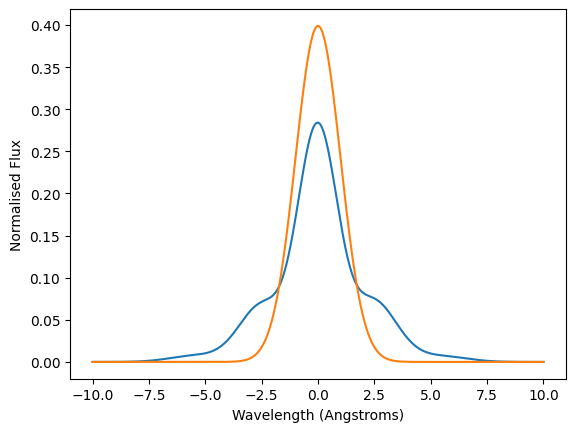

In [14]:
x_vals = np.linspace(-10,10,1001)
y_wing = losvd(x_vals,fwhm_scale(2.355,klist_wing)) #fwhm_scale scales the shape of the LSF to an arbitrary FWHM
y_gaus = losvd(x_vals,klist_gau)

plt.plot(x_vals,y_wing)
plt.plot(x_vals,y_gaus)

plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalised Flux')

## Load Template and Target Spectrum sigma 

This is the instrument dependent resolution for both the stellar library (template spectrum) and IFS instrument (target spectrum)

In [15]:
spec_res_lam  = np.array([4650,5000,5500,6000,6500,7000,7500,8000,8500,9000,9350])
spec_res      = np.array([1609,1750,1978,2227,2484,2737,2975,3183,3350,3465,3506])

spec_fwhm = spec_res_lam/spec_res

sigma_MUSE = interp1d(spec_res_lam,spec_fwhm/fwhm_factor, kind='cubic')(lam_lin)
sigma_EMILES = 2.51*np.ones(len(lam_lin))/fwhm_factor

## Generate Template and Target Spectrum

This generates the template and target spectrum in a way typical of integral field data. The MARCS template is loaded and interpoalted onto a linear wavelength grid. The template spectrum is then generated by applying the LSF with the convolve_variable_lsf function. The Target spectrum is generated with the target_spectrum function. This works by applying the variable LSF convolution with the input spectrum and then log rebinning and convolving with the LOSVD.

In [22]:
#Load in MARCS Template
lam,flux,age,metal = load_marcs(lam_range=[4000,10000],return_pop=1)
template = flux.T[7] #select Age = 10 metal = 0

#Interpolation onto linearly spaced grid
lam_lin  = np.linspace(4650,9300,int((9300-4650)/1.25)+1)
spec_lin = np.interp(lam_lin,lam,template)


#Load in linearly spaced template spectrum
spec_template = convolve_variable_lsf(lam_lin, spec_lin, sigma_EMILES, klist_box,oversample=10,cubic=1)

#Load in logarithmically spaced target spectrum
#(This is exactly the spectrum you want to fit with pPXF)
true_kinematics = np.array([0,100.0,0,.1])
lam_target,    spec_target =   target_spectrum(lam_lin,spec_lin,sigma_MUSE,klist_wing,true_kinematics,lam_range=[4800,8950.0],cubic=1)


# Perform Matching Convolution

## Matching Convolution

This is the key piece of code that will replace the standard gaussian convolution in most spectral fitting pipelines.

In [23]:
velscale = c*np.diff(np.log(lam_target))[0]

#generates a log rebinned template spectrum
lam_temp,temp_matched = template_spectrum_mitigate_variable_hann(lam_lin,spec_template,sigma_EMILES,sigma_MUSE,klist_box,klist_wing,
                                                        velscale=velscale,factor=1,block=5)

## Confirm Results with pPXF

At this point the matching convolution has been performed. We can double check that it has been applied correctly by doing a pPXF fit and confirming that we recover the input kinematics to within the expected tolerance

In [24]:
#Confirm that a pPXF fit returns the true kinematics 
noise = np.ones(len(spec_target))
start = [0,100]
pp_out = ppxf(temp_matched, spec_target, noise, velscale, start, degree=-1,
                  lam=lam_target, lam_temp=lam_temp,moments=4)

 Best Fit:       Vel     sigma        h3        h4
 comp.  0:        -0       100    -0.000     0.098
chi2/DOF: 2.146e+48; DOF: 4631; degree = -1; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 22; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/1
Templates weights:
      1.13
